# Wordle Solver - Interactive Notebook

This notebook provides an interactive interface to use the intelligent Wordle solver.

## How It Works

The solver uses **information theory** to find optimal guesses:
1. Calculates expected information gain for each candidate word
2. Selects the word that maximizes information (minimizes remaining possibilities)
3. Uses heuristics for longer words to keep computation time reasonable

## Feedback Format

Enter results as a string of digits:
- `0` = Gray (letter not in word)
- `1` = Yellow (letter in word, wrong position)
- `2` = Green (letter in correct position)

Example: For the word "SAINE" with result ⬜🟨⬜🟩⬜, enter `01020`

## Setup

Import the solver and initialize it.

In [1]:
import sys
from pathlib import Path

# Add src to path
sys.path.insert(0, str(Path.cwd().parent / 'src'))

from solver import WordleSolver

## Initialize Solver

Choose word length (5-9 letters) and set time tolerance.

In [2]:
# Configuration
WORD_LENGTH = 5  # Change to 6, 7, 8, or 9 for different word lengths
TOLERANCE = 17   # Maximum computation time in seconds

# Initialize solver
solver = WordleSolver(word_length=WORD_LENGTH, tolerance=TOLERANCE)

print(f"Solver initialized for {WORD_LENGTH}-letter words")
print(f"Dictionary size: {len(solver.liste_mot)} words")

Loaded 3950 words of length 5
Solver initialized for 5-letter words
Dictionary size: 3950 words


## Method 1: Step-by-Step Solving

Use this method for manual control over each guess.

In [24]:
# Reset solver to initial state
solver.reset()

print(f"Starting with {len(solver.li_poss_mot)} possible words")

Starting with 3950 possible words


In [19]:
# Get next best guess
suggestions, info_gain, elapsed = solver.get_next_guess(n_suggestions=5, verbose=True)

print(f"\n🎯 Recommended word: {suggestions[0]}")
print(f"📊 Expected information gain: {info_gain:.3f} bits")

if len(suggestions) > 1:
    print(f"\n📝 Other good options: {suggestions[1:]}")

Estimated time: 1859.01s
Remaining possible words: 3950
Applying heuristics (tolerance: 17s)...
nouveau temps estimé:  16.942881875618156
Computation time: 11.33s

🎯 Recommended word: taris
📊 Expected information gain: 6.821 bits

📝 Other good options: ['tares', 'tarie', 'tores', 'sorte']


In [25]:
# Apply feedback from the game
# Change these values based on your game result

guessed_word = "saine"  # The word you guessed
result = "01020"         # Result from game (0=gray, 1=yellow, 2=green)

remaining = solver.apply_feedback(guessed_word, result)

print(f"Remaining possible words: {remaining}")

if remaining <= 10:
    print(f"\nPossible words: {solver.get_possible_words()}")

Remaining possible words: 23


**Repeat the two cells above** (get guess → apply feedback) until you find the solution!

## Method 2: Automatic Solving Session

Let the solver guide you through the entire process interactively.

In [ ]:
# Reset and start interactive session
solver.reset()
solution = solver.solve_interactive()

## Analyze Algorithm Performance

Explore how the algorithm performs on different words.

In [3]:
# Test the solver on a specific word
from utils import resultat, dico_mot, verif

def simulate_game(solver, target_word, max_guesses=6, verbose=True):
    """
    Simulate solving a specific target word.
    
    Returns:
        tuple: (success, number_of_guesses, guess_history)
    """
    solver.reset()
    guesses = []
    
    target_is_duplicate = verif(target_word)
    
    for guess_num in range(1, max_guesses + 1):
        if verbose:
            print(f"\n--- Guess {guess_num} ---")
        
        # Get suggestion
        suggestions, info_gain, elapsed = solver.get_next_guess(n_suggestions=1, verbose=verbose)
        
        if not suggestions:
            return (False, guess_num - 1, guesses)
        
        guess = suggestions[0]
        guesses.append(guess)
        
        if verbose:
            print(f"Guessing: {guess}")
        
        # Check if correct
        if guess == target_word:
            if verbose:
                print(f"\n🎉 Found in {guess_num} guesses!")
            return (True, guess_num, guesses)
        
        # Generate feedback
        guess_is_duplicate = verif(guess)
        
        # If either word has duplicates, both need to be in dictionary format
        if guess_is_duplicate or target_is_duplicate:
            guess_dict = dico_mot(guess)
            target_dict = dico_mot(target_word)
            result = resultat(guess_dict, target_dict, True, solver.word_length)
        else:
            result = resultat(guess, target_word, False, solver.word_length)
        
        if verbose:
            print(f"Result: {result}")
        
        # Apply feedback
        remaining = solver.apply_feedback(guess, result)
        
        if verbose:
            print(f"Remaining: {remaining} words")
    
    if verbose:
        print(f"\n❌ Failed to find word in {max_guesses} guesses")
    return (False, max_guesses, guesses)

# Example: Test on a word
test_word = "arbre"  # Change this to test different words
success, num_guesses, history = simulate_game(solver, test_word, max_guesses=6, verbose=True)

print(f"\n{'='*50}")
print(f"Target word: {test_word}")
print(f"Success: {success}")
print(f"Number of guesses: {num_guesses}")
print(f"Guess history: {' → '.join(history)}")


--- Guess 1 ---
Estimated time: 1859.01s
Remaining possible words: 3950
Applying heuristics (tolerance: 17s)...
nouveau temps estimé:  16.942881875618156
Computation time: 10.66s
Guessing: taris
Result: 01100
Remaining: 101 words

--- Guess 2 ---
Estimated time: 47.53s
Remaining possible words: 101
Applying heuristics (tolerance: 17s)...
nouveau temps estimé:  16.99197095672051
Computation time: 13.44s
Guessing: brune
Result: 12002
Remaining: 3 words

--- Guess 3 ---
Estimated time: 1.41s
Remaining possible words: 3
Master words (possible):  ['arabe', 'arbre', 'crabe']
Computation time: 0.11s
Guessing: arabe
Result: 22012
Remaining: 1 words

--- Guess 4 ---
Estimated time: 0.47s
Remaining possible words: 1
Master words (possible):  ['arbre']
Computation time: 0.06s
Guessing: arbre

🎉 Found in 4 guesses!

Target word: arbre
Success: True
Number of guesses: 4
Guess history: taris → brune → arabe → arbre


## Batch Performance Analysis

Test the solver against multiple words to measure average performance.

Testing 1/20: rosse nouveau temps estimé:  16.942881875618156
Master words (possible):  ['rosse']
✓ (3 guesses)
Testing 2/20: omega nouveau temps estimé:  16.942881875618156
nouveau temps estimé:  16.98506035792455
Master words (possible):  ['omega']
✓ (3 guesses)
Testing 3/20: emirs nouveau temps estimé:  16.942881875618156
Master words (possible):  ['emirs']
✓ (3 guesses)
Testing 4/20: lifte nouveau temps estimé:  16.942881875618156
nouveau temps estimé:  16.993281587526642
Master words (possible):  ['lifte']
✓ (4 guesses)
Testing 5/20: silos nouveau temps estimé:  16.942881875618156
nouveau temps estimé:  16.990064584638866
Master words (possible):  ['kilos', 'silos']
Master words (possible):  ['silos']
✓ (4 guesses)
Testing 6/20: niais nouveau temps estimé:  16.942881875618156
Master words (possible):  ['niais']
✓ (3 guesses)
Testing 7/20: smurf nouveau temps estimé:  16.942881875618156
Master words (possible):  ['smurf']
✓ (3 guesses)
Testing 8/20: reacs nouveau temps estimé:  16.

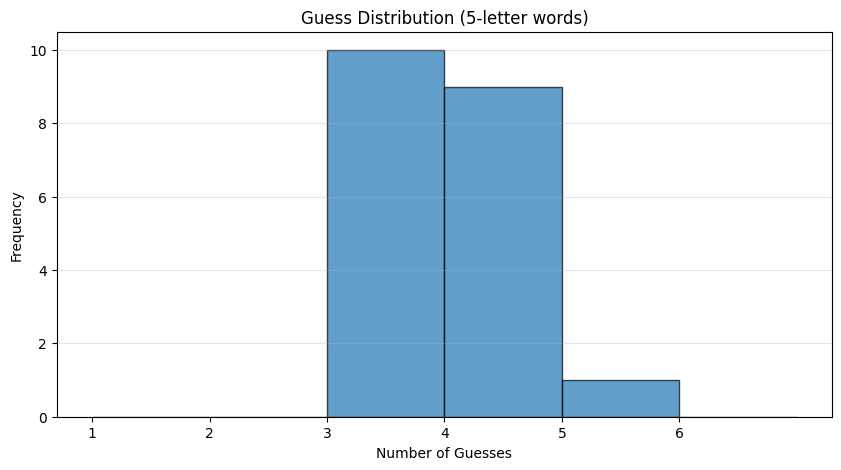

In [4]:
import random
import numpy as np
import matplotlib.pyplot as plt

def batch_test(solver, num_words=20, max_guesses=6):
    """
    Test solver on multiple random words.
    """
    # Select random words
    test_words = random.sample(solver.liste_mot, min(num_words, len(solver.liste_mot)))
    
    results = []
    
    for i, word in enumerate(test_words, 1):
        print(f"Testing {i}/{len(test_words)}: {word}", end=" ")
        success, num_guesses, history = simulate_game(solver, word, max_guesses, verbose=False)
        results.append({
            'word': word,
            'success': success,
            'guesses': num_guesses,
            'history': history
        })
        print(f"{'✓' if success else '✗'} ({num_guesses} guesses)")
    
    return results

# Run batch test
results = batch_test(solver, num_words=20, max_guesses=6)

# Analyze results
successes = [r for r in results if r['success']]
failures = [r for r in results if not r['success']]

print(f"\n{'='*50}")
print(f"Success rate: {len(successes)}/{len(results)} ({100*len(successes)/len(results):.1f}%)")

if successes:
    guess_counts = [r['guesses'] for r in successes]
    print(f"Average guesses: {np.mean(guess_counts):.2f}")
    print(f"Median guesses: {np.median(guess_counts):.1f}")
    print(f"Min/Max guesses: {min(guess_counts)}/{max(guess_counts)}")
    
    # Plot distribution
    plt.figure(figsize=(10, 5))
    plt.hist(guess_counts, bins=range(1, 8), edgecolor='black', alpha=0.7)
    plt.xlabel('Number of Guesses')
    plt.ylabel('Frequency')
    plt.title(f'Guess Distribution ({WORD_LENGTH}-letter words)')
    plt.xticks(range(1, 7))
    plt.grid(axis='y', alpha=0.3)
    plt.show()

## Custom Word List Analysis

Analyze specific words of interest.

In [6]:
# Test on specific words
custom_words = ['adage', 'saint', 'legal', 'cabot', 'virus']  # Add your words here

print(f"Testing custom word list...\n")

for word in custom_words:
    if word not in solver.liste_mot:
        print(f"⚠️  '{word}' not in dictionary")
        continue
    
    print(f"\n{'-'*50}")
    success, num_guesses, history = simulate_game(solver, word, max_guesses=6, verbose=False)
    
    print(f"Word: {word.upper()}")
    print(f"Result: {'✓ Success' if success else '✗ Failed'}")
    print(f"Guesses: {num_guesses}")
    print(f"Path: {' → '.join(history)}")

Testing custom word list...


--------------------------------------------------
nouveau temps estimé:  16.942881875618156
nouveau temps estimé:  16.98506035792455
Master words (possible):  ['adage']
Word: ADAGE
Result: ✓ Success
Guesses: 4
Path: taris → clone → agape → adage

--------------------------------------------------
nouveau temps estimé:  16.942881875618156
Master words (possible):  ['saint']
Word: SAINT
Result: ✓ Success
Guesses: 2
Path: taris → saint

--------------------------------------------------
nouveau temps estimé:  16.942881875618156
nouveau temps estimé:  16.98506035792455
Master words (possible):  ['kebla', 'melba']
Master words (possible):  ['legal']
Word: LEGAL
Result: ✓ Success
Guesses: 4
Path: taris → clone → kebla → legal

--------------------------------------------------
nouveau temps estimé:  16.942881875618156
nouveau temps estimé:  16.997690072965447
Master words (possible):  ['cabot']
Word: CABOT
Result: ✓ Success
Guesses: 4
Path: taris → ponte → buch

## Tips for Best Results

1. **Start Fresh**: Always call `solver.reset()` before starting a new game
2. **Be Accurate**: Double-check feedback codes (0, 1, 2) - incorrect feedback will lead to wrong suggestions
3. **Adjust Tolerance**: For 9-letter words, increase tolerance if you can wait longer for better accuracy
4. **Alternative Guesses**: Consider the alternative suggestions when the top word doesn't feel right
5. **Master Words**: When the solver finds a "master word", it guarantees optimal information gain

## Next Steps

- Try different word lengths (6-9 letters)
- Experiment with tolerance values
- Analyze performance on specific word categories
- Export results for further analysis